
Displaying Membership Functions...


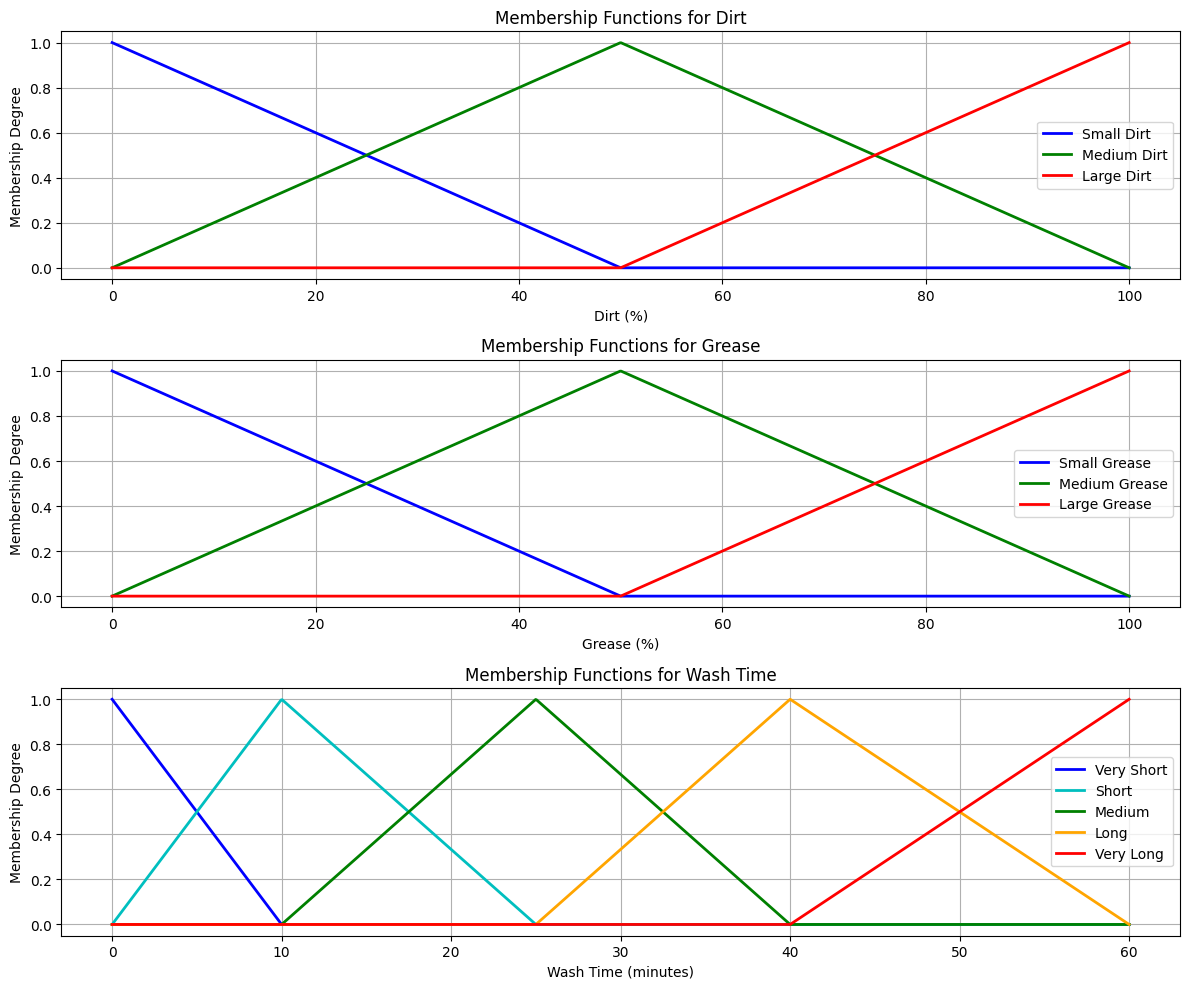

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class WashingMachineFuzzyController:
    def __init__(self):
        pass

    # Dirt membership functions
    def dirt_small(self, x):
        return max(0, (50 - x) / 50) if 0 <= x <= 50 else 0

    def dirt_medium(self, x):
        if 0 <= x <= 50:
            return x / 50
        elif 50 < x <= 100:
            return (100 - x) / 50
        return 0

    def dirt_large(self, x):
        return max(0, (x - 50) / 50) if 50 <= x <= 100 else 0

    # Grease membership functions
    def grease_small(self, y):
        return max(0, (50 - y) / 50) if 0 <= y <= 50 else 0

    def grease_medium(self, y):
        if 0 <= y <= 50:
            return y / 50
        elif 50 < y <= 100:
            return (100 - y) / 50
        return 0

    def grease_large(self, y):
        return max(0, (y - 50) / 50) if 50 <= y <= 100 else 0

    # Wash time membership functions
    def wash_very_short(self, z):
        return max(0, (10 - z) / 10) if 0 <= z <= 10 else 0

    def wash_short(self, z):
        if 0 <= z <= 10:
            return z / 10
        elif 10 < z <= 25:
            return (25 - z) / 15
        return 0

    def wash_medium(self, z):
        if 10 <= z <= 25:
            return (z - 10) / 15
        elif 25 < z <= 40:
            return (40 - z) / 15
        return 0

    def wash_long(self, z):
        if 25 <= z <= 40:
            return (z - 25) / 15
        elif 40 < z <= 60:
            return (60 - z) / 20
        return 0

    def wash_very_long(self, z):
        return max(0, (z - 40) / 20) if 40 <= z <= 60 else 0

    def compute_wash_time(self, dirt, grease):
        print("\n" + "="*70)
        print(f"COMPUTING WASH TIME: Dirt={dirt}%, Grease={grease}%")
        print("="*70)

        # Step 1: Fuzzification
        print("\n[Step 1] Fuzzification:")
        print("-" * 50)
        dirt_sd = self.dirt_small(dirt)
        dirt_md = self.dirt_medium(dirt)
        dirt_ld = self.dirt_large(dirt)
        grease_sg = self.grease_small(grease)
        grease_mg = self.grease_medium(grease)
        grease_lg = self.grease_large(grease)

        print(f"  Dirt ({dirt}%):")
        print(f"    μ_SD({dirt}) = {dirt_sd:.3f} (Small Dirt)")
        print(f"    μ_MD({dirt}) = {dirt_md:.3f} (Medium Dirt)")
        print(f"    μ_LD({dirt}) = {dirt_ld:.3f} (Large Dirt)")

        print(f"\n  Grease ({grease}%):")
        print(f"    μ_SG({grease}) = {grease_sg:.3f} (Small Grease)")
        print(f"    μ_MG({grease}) = {grease_mg:.3f} (Medium Grease)")
        print(f"    μ_LG({grease}) = {grease_lg:.3f} (Large Grease)")

        # Step 2: Rule Evaluation (AND = min)
        print("\n[Step 2] Rule Evaluation (AND = min):")
        print("-" * 50)
        rules = {
            'VS': min(dirt_sd, grease_sg),  # SD & SG -> VS
            'S': min(dirt_md, grease_sg),   # MD & SG -> S
            'M1': min(dirt_sd, grease_mg),  # SD & MG -> M
            'M2': min(dirt_md, grease_mg),  # MD & MG -> M
            'M3': min(dirt_ld, grease_sg),  # LD & SG -> M
            'L1': min(dirt_sd, grease_lg),  # SD & LG -> L
            'L2': min(dirt_md, grease_lg),  # MD & LG -> L
            'L3': min(dirt_ld, grease_mg),  # LD & MG -> L
            'VL': min(dirt_ld, grease_lg)   # LD & LG -> VL
        }

        rule_names = {
            'VS': 'SD & SG -> VS',
            'S': 'MD & SG -> S',
            'M1': 'SD & MG -> M',
            'M2': 'MD & MG -> M',
            'M3': 'LD & SG -> M',
            'L1': 'SD & LG -> L',
            'L2': 'MD & LG -> L',
            'L3': 'LD & MG -> L',
            'VL': 'LD & LG -> VL'
        }

        for rule, strength in rules.items():
            if strength > 0:
                print(f"  Rule: IF {rule_names[rule]} THEN Wash Time = {rule}")
                print(f"    Strength = {strength:.3f}")

        # Step 3: Aggregation (OR = max)
        print("\n[Step 3] Aggregation (OR = max):")
        print("-" * 50)
        agg_vs = rules['VS']
        agg_s = rules['S']
        agg_m = max(rules['M1'], rules['M2'], rules['M3'])
        agg_l = max(rules['L1'], rules['L2'], rules['L3'])
        agg_vl = rules['VL']

        print(f"  Very Short (VS): {agg_vs:.3f}")
        print(f"  Short (S):       {agg_s:.3f}")
        print(f"  Medium (M):      {agg_m:.3f}")
        print(f"  Long (L):        {agg_l:.3f}")
        print(f"  Very Long (VL):  {agg_vl:.3f}")

        # Step 4: Defuzzification - MAX MEMBERSHIP METHOD
        print("\n[Step 4] Defuzzification - Max Membership (Height) Method:")
        print("-" * 50)

        # Find the label with maximum membership value
        agg_dict = {'VS': agg_vs, 'S': agg_s, 'M': agg_m, 'L': agg_l, 'VL': agg_vl}

        # Check if all values are zero (edge case)
        if all(value == 0 for value in agg_dict.values()):
            print("  WARNING: All membership values are zero. Using default wash time.")
            default_time = 25.0  # Default medium wash time
            print(f"  Default Wash Time = {default_time:.1f} minutes")
            return default_time

        max_label = max(agg_dict, key=agg_dict.get)
        max_value = agg_dict[max_label]

        print(f"  Maximum membership: {max_label} = {max_value:.3f}")

        crisp_values = []

        if max_label == 'VS':
            # (10-z)/10 = max_value -> z = 10 - 10*max_value
            z = 10 - 10 * max_value
            crisp_values.append(z)
            print(f"  Very Short: z = 10 - 10*{max_value:.3f} = {z:.1f}")

        elif max_label == 'S':
            # For 0 <= z <= 10: z/10 = max_value -> z = 10*max_value
            z1 = 10 * max_value
            crisp_values.append(z1)
            print(f"  Short: z1 = 10*{max_value:.3f} = {z1:.1f}")

            # For 10 < z <= 25: (25-z)/15 = max_value -> z = 25 - 15*max_value
            z2 = 25 - 15 * max_value
            crisp_values.append(z2)
            print(f"  Short: z2 = 25 - 15*{max_value:.3f} = {z2:.1f}")

        elif max_label == 'M':
            # For 10 <= z <= 25: (z-10)/15 = max_value -> z = 10 + 15*max_value
            z1 = 10 + 15 * max_value
            crisp_values.append(z1)
            print(f"  Medium: z1 = 10 + 15*{max_value:.3f} = {z1:.1f}")

            # For 25 < z <= 40: (40-z)/15 = max_value -> z = 40 - 15*max_value
            z2 = 40 - 15 * max_value
            crisp_values.append(z2)
            print(f"  Medium: z2 = 40 - 15*{max_value:.3f} = {z2:.1f}")

        elif max_label == 'L':
            # For 25 <= z <= 40: (z-25)/15 = max_value -> z = 25 + 15*max_value
            z1 = 25 + 15 * max_value
            crisp_values.append(z1)
            print(f"  Long: z1 = 25 + 15*{max_value:.3f} = {z1:.1f}")

            # For 40 < z <= 60: (60-z)/20 = max_value -> z = 60 - 20*max_value
            z2 = 60 - 20 * max_value
            crisp_values.append(z2)
            print(f"  Long: z2 = 60 - 20*{max_value:.3f} = {z2:.1f}")

        elif max_label == 'VL':
            # (z-40)/20 = max_value -> z = 40 + 20*max_value
            z = 40 + 20 * max_value
            crisp_values.append(z)
            print(f"  Very Long: z = 40 + 20*{max_value:.3f} = {z:.1f}")

        # Take the average of all crisp values
        crisp_output = sum(crisp_values) / len(crisp_values)

        # Clamp the output to valid range (0-60 minutes)
        crisp_output = max(0, min(60, crisp_output))

        print(f"\n  Crisp values: {crisp_values}")
        print(f"  Average = ({' + '.join([f'{v:.1f}' for v in crisp_values])}) / {len(crisp_values)} = {crisp_output:.1f}")

        print(f"Recommended Wash Time = {crisp_output:.1f} minutes")

        # Plot inference visualization with the input values
        self.plot_inference(dirt, grease, crisp_output, agg_dict)

        return crisp_output

    def plot_membership_functions(self):
        fig, axes = plt.subplots(3, 1, figsize=(12, 10))

        # Dirt membership functions
        x = np.linspace(0, 100, 1000)
        axes[0].plot(x, [self.dirt_small(xi) for xi in x], 'b-', label='Small Dirt', linewidth=2)
        axes[0].plot(x, [self.dirt_medium(xi) for xi in x], 'g-', label='Medium Dirt', linewidth=2)
        axes[0].plot(x, [self.dirt_large(xi) for xi in x], 'r-', label='Large Dirt', linewidth=2)
        axes[0].set_xlabel('Dirt (%)')
        axes[0].set_ylabel('Membership Degree')
        axes[0].set_title('Membership Functions for Dirt')
        axes[0].legend()
        axes[0].grid(True)

        # Grease membership functions
        axes[1].plot(x, [self.grease_small(xi) for xi in x], 'b-', label='Small Grease', linewidth=2)
        axes[1].plot(x, [self.grease_medium(xi) for xi in x], 'g-', label='Medium Grease', linewidth=2)
        axes[1].plot(x, [self.grease_large(xi) for xi in x], 'r-', label='Large Grease', linewidth=2)
        axes[1].set_xlabel('Grease (%)')
        axes[1].set_ylabel('Membership Degree')
        axes[1].set_title('Membership Functions for Grease')
        axes[1].legend()
        axes[1].grid(True)

        # Wash Time membership functions
        z = np.linspace(0, 60, 1000)
        axes[2].plot(z, [self.wash_very_short(zi) for zi in z], 'b-', label='Very Short', linewidth=2)
        axes[2].plot(z, [self.wash_short(zi) for zi in z], 'c-', label='Short', linewidth=2)
        axes[2].plot(z, [self.wash_medium(zi) for zi in z], 'g-', label='Medium', linewidth=2)
        axes[2].plot(z, [self.wash_long(zi) for zi in z], 'orange', label='Long', linewidth=2)
        axes[2].plot(z, [self.wash_very_long(zi) for zi in z], 'r-', label='Very Long', linewidth=2)
        axes[2].set_xlabel('Wash Time (minutes)')
        axes[2].set_ylabel('Membership Degree')
        axes[2].set_title('Membership Functions for Wash Time')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_inference(self, dirt, grease, wash_time, agg_dict):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Dirt membership with input marked
        x = np.linspace(0, 100, 1000)
        axes[0, 0].plot(x, [self.dirt_small(xi) for xi in x], 'b-', label='Small Dirt', linewidth=2)
        axes[0, 0].plot(x, [self.dirt_medium(xi) for xi in x], 'g-', label='Medium Dirt', linewidth=2)
        axes[0, 0].plot(x, [self.dirt_large(xi) for xi in x], 'r-', label='Large Dirt', linewidth=2)
        axes[0, 0].axvline(x=dirt, color='purple', linestyle='--', linewidth=2, label=f'Dirt = {dirt}%')
        axes[0, 0].set_xlabel('Dirt (%)')
        axes[0, 0].set_ylabel('Membership Degree')
        axes[0, 0].set_title('Dirt Membership Functions')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # Grease membership with input marked
        axes[0, 1].plot(x, [self.grease_small(xi) for xi in x], 'b-', label='Small Grease', linewidth=2)
        axes[0, 1].plot(x, [self.grease_medium(xi) for xi in x], 'g-', label='Medium Grease', linewidth=2)
        axes[0, 1].plot(x, [self.grease_large(xi) for xi in x], 'r-', label='Large Grease', linewidth=2)
        axes[0, 1].axvline(x=grease, color='purple', linestyle='--', linewidth=2, label=f'Grease = {grease}%')
        axes[0, 1].set_xlabel('Grease (%)')
        axes[0, 1].set_ylabel('Membership Degree')
        axes[0, 1].set_title('Grease Membership Functions')
        axes[0, 1].legend()
        axes[0, 1].grid(True)

        # Wash Time membership with result marked
        z = np.linspace(0, 60, 1000)
        axes[1, 0].plot(z, [self.wash_very_short(zi) for zi in z], 'b-', label='Very Short', linewidth=2)
        axes[1, 0].plot(z, [self.wash_short(zi) for zi in z], 'c-', label='Short', linewidth=2)
        axes[1, 0].plot(z, [self.wash_medium(zi) for zi in z], 'g-', label='Medium', linewidth=2)
        axes[1, 0].plot(z, [self.wash_long(zi) for zi in z], 'orange', label='Long', linewidth=2)
        axes[1, 0].plot(z, [self.wash_very_long(zi) for zi in z], 'r-', label='Very Long', linewidth=2)
        axes[1, 0].axvline(x=wash_time, color='red', linestyle='-', linewidth=3, label=f'Wash Time = {wash_time:.1f} min')
        axes[1, 0].set_xlabel('Wash Time (minutes)')
        axes[1, 0].set_ylabel('Membership Degree')
        axes[1, 0].set_title('Wash Time Membership Functions')
        axes[1, 0].legend()
        axes[1, 0].grid(True)

        # Aggregated output
        agg_labels = ['VS', 'S', 'M', 'L', 'VL']
        agg_values = [agg_dict['VS'], agg_dict['S'], agg_dict['M'], agg_dict['L'], agg_dict['VL']]
        colors = ['blue', 'cyan', 'green', 'orange', 'red']

        bars = axes[1, 1].bar(agg_labels, agg_values, color=colors, alpha=0.7, edgecolor='black')
        axes[1, 1].set_xlabel('Wash Time Category')
        axes[1, 1].set_ylabel('Membership Degree')
        axes[1, 1].set_title('Aggregated Output Membership Values')
        axes[1, 1].set_ylim(0, 1)
        axes[1, 1].grid(True, axis='y')

        # Add value labels on bars
        for bar, value in zip(bars, agg_values):
            axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                           f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        # Highlight the max value
        max_idx = np.argmax(agg_values)
        if max(agg_values) > 0:
            bars[max_idx].set_color('darkgreen')
            bars[max_idx].set_edgecolor('black')
            bars[max_idx].set_linewidth(3)

        plt.suptitle(f'Fuzzy Inference for Dirt={dirt}%, Grease={grease}%\nWash Time = {wash_time:.1f} minutes',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Create controller instance and run the program
controller = WashingMachineFuzzyController()

print("\nDisplaying Membership Functions...")
controller.plot_membership_functions()



Enter dirt percentage (0-100): 60
Enter grease percentage (0-100): 70

COMPUTING WASH TIME: Dirt=60.0%, Grease=70.0%

[Step 1] Fuzzification:
--------------------------------------------------
  Dirt (60.0%):
    μ_SD(60.0) = 0.000 (Small Dirt)
    μ_MD(60.0) = 0.800 (Medium Dirt)
    μ_LD(60.0) = 0.200 (Large Dirt)

  Grease (70.0%):
    μ_SG(70.0) = 0.000 (Small Grease)
    μ_MG(70.0) = 0.600 (Medium Grease)
    μ_LG(70.0) = 0.400 (Large Grease)

[Step 2] Rule Evaluation (AND = min):
--------------------------------------------------
  Rule: IF MD & MG -> M THEN Wash Time = M2
    Strength = 0.600
  Rule: IF MD & LG -> L THEN Wash Time = L2
    Strength = 0.400
  Rule: IF LD & MG -> L THEN Wash Time = L3
    Strength = 0.200
  Rule: IF LD & LG -> VL THEN Wash Time = VL
    Strength = 0.200

[Step 3] Aggregation (OR = max):
--------------------------------------------------
  Very Short (VS): 0.000
  Short (S):       0.000
  Medium (M):      0.600
  Long (L):        0.400
  Very Long 

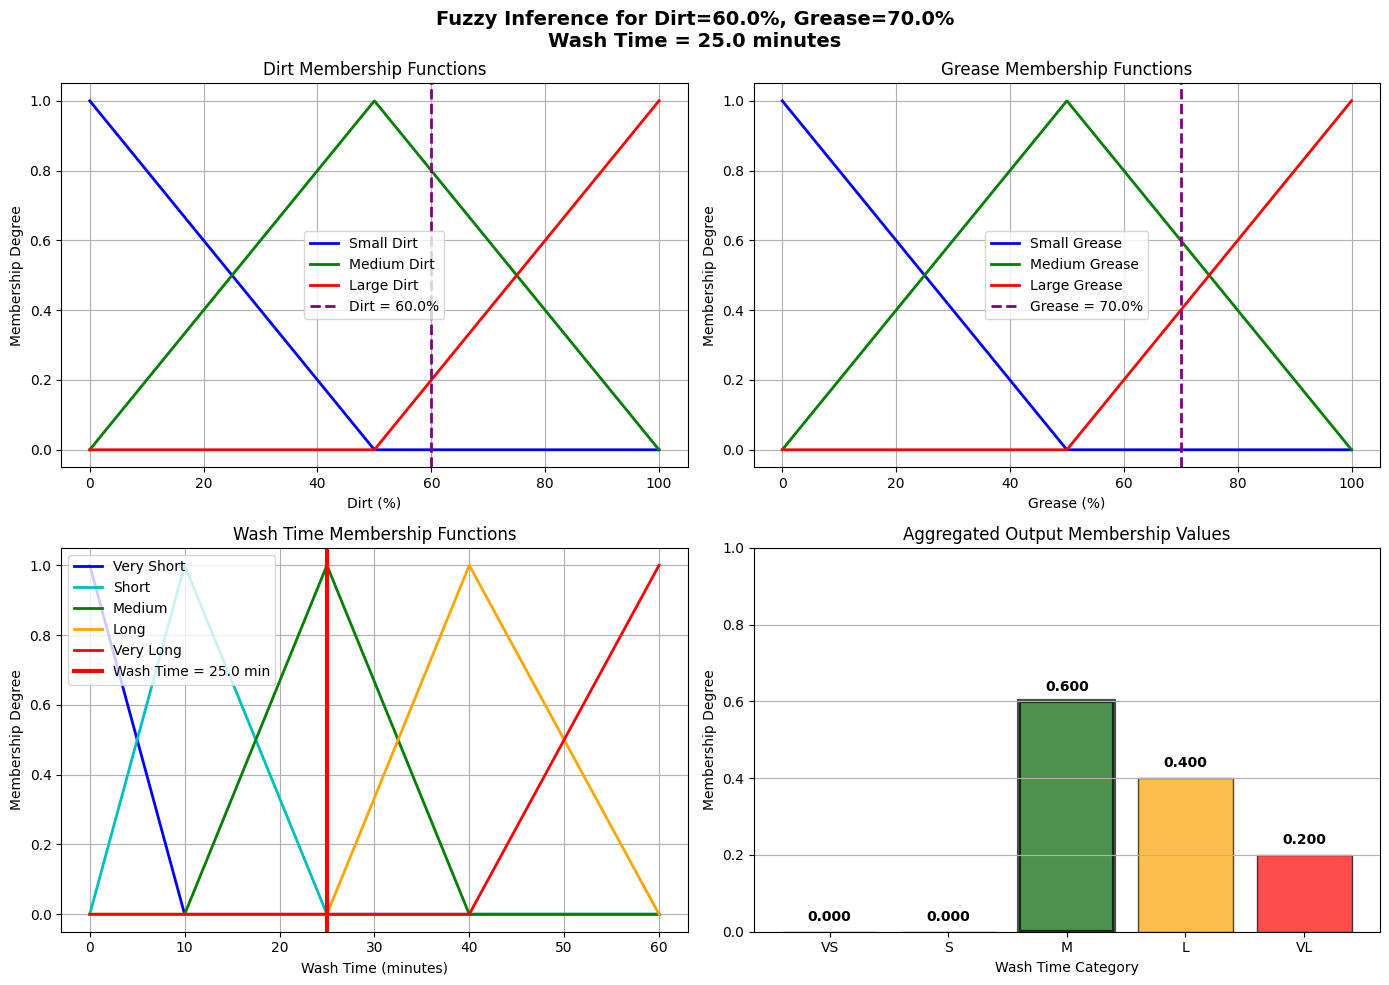

In [ ]:
# Get dirt input from user
while True:
    try:
        dirt = float(input("Enter dirt percentage (0-100): "))
        if 0 <= dirt <= 100:
            break
        else:
            print("Please enter a value between 0 and 100")
    except ValueError:
        print("Please enter a valid number")

# Get grease input from user
while True:
    try:
        grease = float(input("Enter grease percentage (0-100): "))
        if 0 <= grease <= 100:
            break
        else:
            print("Please enter a value between 0 and 100")
    except ValueError:
        print("Please enter a valid number")

wash_time = controller.compute_wash_time(dirt, grease)

In [ ]:
print("   Dirt \\ Grease |  SG  |  MG  |  LG  |")
print("   ---------------+------+------+------+")
print("   SD (Small)    |  VS  |  M   |  L   |")
print("   MD (Medium)   |  S   |  M   |  L   |")
print("   LD (Large)    |  M   |  L   |  VL  |")
print()
print(f"   For clothes with {dirt}% dirt and {grease}% grease:")
print(f"   Recommended Wash Time = {wash_time:.1f} minutes")

   Dirt \ Grease |  SG  |  MG  |  LG  |
   ---------------+------+------+------+
   SD (Small)    |  VS  |  M   |  L   |
   MD (Medium)   |  S   |  M   |  L   |
   LD (Large)    |  M   |  L   |  VL  |

   For clothes with 60.0% dirt and 70.0% grease:
   Recommended Wash Time = 25.0 minutes
